**There are three major type of hyperparameter tuning:**
1. Grid Search
Try all combinations
Example:
LR = [0.01, 0.001]
Batch = [16, 32]

➡️ Total = 4 combinations

✅ Pros: Exhaustive

❌ Cons: Very slow

2. Random Search
Randomly sample combinations

👉 Surprisingly better than grid search in many cases because:

Not all hyperparameters are equally important


3. Bayesian Optimization
Uses past results to choose next best combination
Smarter search (e.g., Optuna, Hyperopt)

✅ Faster convergence
✅ Industry preferred

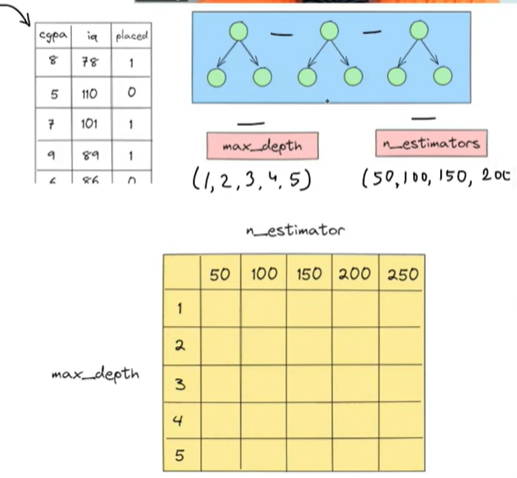

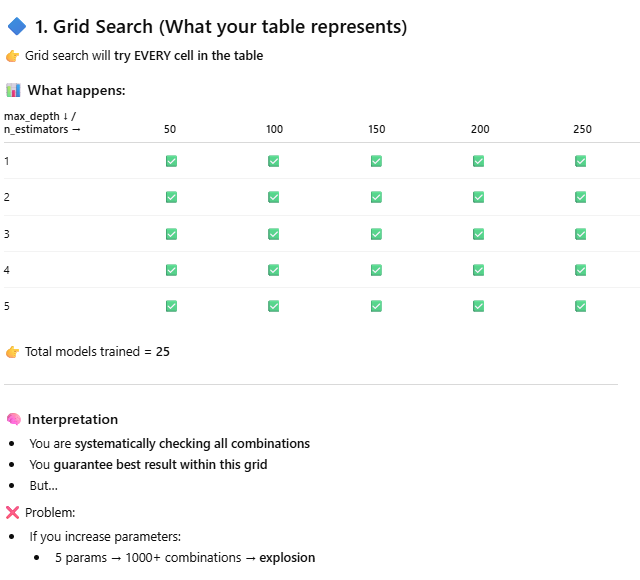

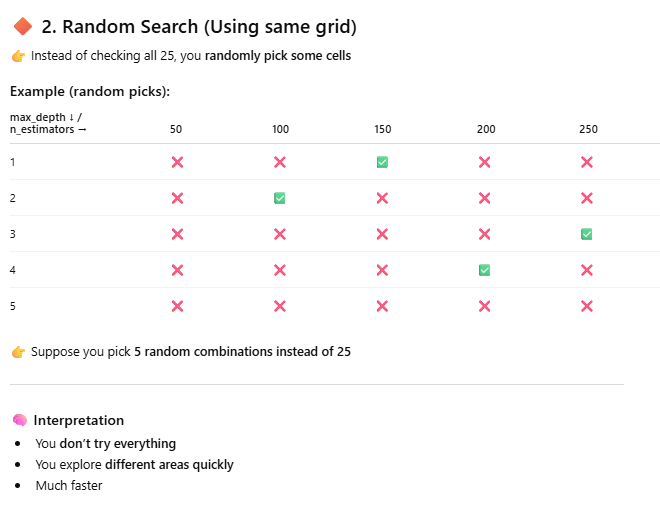

**Bayesian**

It consider the accuracy is the function of max_depth and n_estimators and trues to find the max_depth and n_estimator who can give high accuracy.

to do this, It tries few combination randomly and learn the accuracy from them and this can be achieved through OPTUNA module which works for both DL and ML.



In [ ]:
#**Grid  Search**

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}



grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


grid_search.fit(X_train, y_train)



print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

In [ ]:
# Random Search
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 30),
    'min_samples_split': randint(2, 10)
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,   # Only 10 combinations!
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

**OPTUNA : Bayesian Optimization**

**Key term:**

Study: Collection of trails.

Trail: Single experiment.

Trail Parameter: The Parameter used in Trails.

Objective Function: Relationship between depth and n_estimator.

Sampler: It suggest which parameter will be picked for next trial



In [33]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.cuda import is_available,device


In [5]:
torch.manual_seed(34)

In [6]:
device=("CUDA" if is_available() else "cpu")

In [8]:
device


'CUDA'

In [9]:
#Loading Datasets
df=pd.read_csv("/content/fashion-mnist_train.csv")

In [11]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0,0,105,92,101,107,100,132,0,0,2,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,150,...,211,220,214,74,0,255,222,128,0,0,0,0,0,0,0,0,0,44,12,0,0,40,134,162,191,214,163,146,165,79,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,0,114,183,112,55,23,72,102,165,160,28,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,24,188,163,93,...,171,249,207,197,202,45,0,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,22,21,25,69,52,45,74,39,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,0,0,0,46,0,21,68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,187,189,...,230,237,229,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68,116,112,136,147,144,121,102,63,0,0,0,0,0,0,0,0,0,0


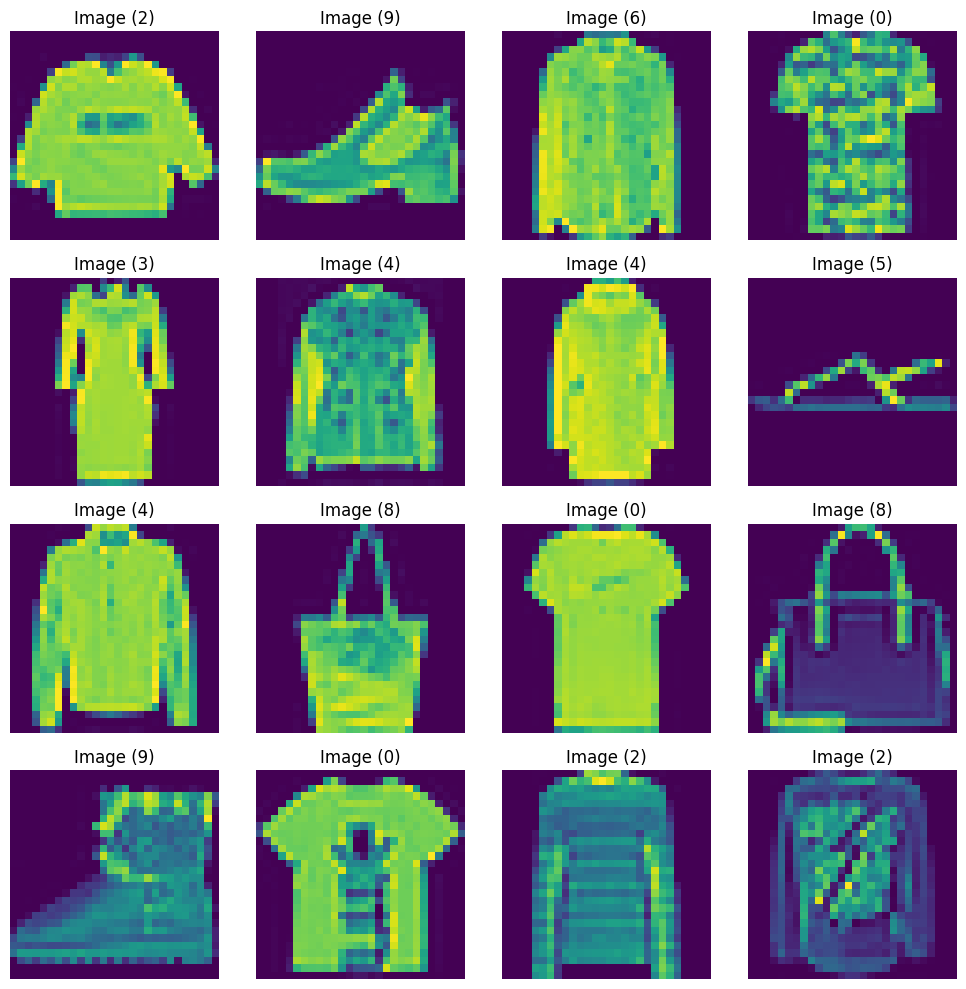

In [21]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(10, 10)) # Creates a 4x4 grid of axes

axes_flat = axes.flatten()
# Now you can iterate through the axes easily
for i, ax in enumerate(axes_flat):
  ax.imshow(df.iloc[i, 1:].values.reshape(28, 28))
  ax.set_title(f"Image ({df.iloc[i,0]})")
  ax.axis('off') # Hides the axes ticks and spines

plt.tight_layout() # Adjusts subplot params for tight layout
plt.show()


In [24]:
#Creating train Test Split
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [25]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [27]:
x_train.shape

(48000, 784)

In [28]:
x_test.shape

(12000, 784)

In [29]:
y_train.shape

(48000,)

In [30]:
##Scaling the X varaibles

x_train_scale=StandardScaler().fit_transform(x_train)
x_test_scale=StandardScaler().fit_transform(x_test)


In [32]:
x_train_scale[0]

784

In [34]:
# Creating CustomDataset Class
class CustomDataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(x,dtype=torch.float32)
    self.y=torch.tensor(y,dtype=torch.float32)

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self,idx):
    return self.x[idx],self.y[idx]



In [36]:

train_Data=CustomDataset(x_train_scale,y_train)
test_Data=CustomDataset(x_test_scale,y_test)


In [37]:
train_loader=DataLoader(train_Data,batch_size=64,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_Data,batch_size=64, shuffle=False,pin_memory=True)

In [ ]:
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

In [38]:
# objective function
def objective(trial):

  # next hyperparameter values from the search space
  """study = optuna.create_study(direction="minimize") --> it created study object
   Once you call study.optimize(objective, n_trials=100) then it trgiiger objective(trail) function
   trial = Trial()              # create object
  objective(trial)             # call your function
   """
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  # optimizer selection
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

  if optimizer_name == 'Adam':
    optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop

  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()


  # evaluation
  model.eval()
  # evaluation on test data
  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

    accuracy = correct/total

  return accuracy

In [ ]:
!pip install optuna

In [ ]:
import optuna

study = optuna.create_study(direction='maximize') # since we are dealing with accuracy so our goal is to maximize

In [ ]:
study.optimize(objective, n_trials=10)

In [ ]:
study.best_value


In [ ]:
study.best_params